In [16]:
import pandas as pd
import numpy as np
import time
from time import time as t

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

In [17]:
df = pd.read_csv('/kaggle/input/datasets/jahnavisingh1234/tweetsss/Tweets.csv')

# Select correct columns
df = df[['text', 'sentiment']]

# Rename for compatibility
df.rename(columns={'sentiment': 'airline_sentiment'}, inplace=True)

df.head()

,text,airline_sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [18]:
# Handle missing values
df = df.dropna(subset=['text'])

# Convert to string
df['text'] = df['text'].astype(str)

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(sequences, maxlen=100)

y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data ready ")

Data ready 


In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [20]:
rnn_model = Sequential([
    Embedding(8000, 64, input_length=100),
    SimpleRNN(64),
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dense(3, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
lstm_model = Sequential([
    Embedding(8000, 64, input_length=100),
    LSTM(64),
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [22]:
start_time = time.time()

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

end_time = time.time()
rnn_time = end_time - start_time

print("RNN Training Time:", rnn_time)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.4282 - loss: 1.0942 - val_accuracy: 0.6193 - val_loss: 0.8742 - learning_rate: 0.0010
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7251 - loss: 0.6944 - val_accuracy: 0.6641 - val_loss: 0.8047 - learning_rate: 0.0010
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8625 - loss: 0.4133 - val_accuracy: 0.6338 - val_loss: 0.9437 - learning_rate: 0.0010
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9378 - loss: 0.2273 - val_accuracy: 0.6252 - val_loss: 1.1584 - learning_rate: 5.0000e-04
RNN Training Time: 16.595981121063232


In [23]:
start = t()

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

end = t()
lstm_time = end - start

print("LSTM Training Time:", lstm_time)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4934 - loss: 1.0114 - val_accuracy: 0.6725 - val_loss: 0.7702 - learning_rate: 0.0010
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7324 - loss: 0.6539 - val_accuracy: 0.6905 - val_loss: 0.7391 - learning_rate: 0.0010
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7824 - loss: 0.5582 - val_accuracy: 0.6836 - val_loss: 0.7545 - learning_rate: 0.0010
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8275 - loss: 0.4812 - val_accuracy: 0.6918 - val_loss: 0.7845 - learning_rate: 5.0000e-04
LSTM Training Time: 11.450043678283691


In [24]:
gru_model = Sequential([
    Embedding(8000, 64, input_length=100),
    GRU(64),
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dense(3, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [25]:
start = t()

history_gru = gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

end = t()
gru_time = end - start

print("GRU Training Time:", gru_time)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4731 - loss: 1.0341 - val_accuracy: 0.6730 - val_loss: 0.7601 - learning_rate: 0.0010
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7482 - loss: 0.6319 - val_accuracy: 0.6982 - val_loss: 0.7191 - learning_rate: 0.0010
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7970 - loss: 0.5285 - val_accuracy: 0.7030 - val_loss: 0.7337 - learning_rate: 0.0010
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8323 - loss: 0.4507 - val_accuracy: 0.7021 - val_loss: 0.7836 - learning_rate: 5.0000e-04
GRU Training Time: 11.129987478256226


In [26]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test, verbose=0)
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
gru_loss, gru_acc = gru_model.evaluate(X_test, y_test, verbose=0)

print("\n===== FINAL RESULTS =====")
print(f"RNN  Accuracy : {rnn_acc:.4f}  |  Time: {rnn_time:.2f} sec")
print(f"LSTM Accuracy : {lstm_acc:.4f}  |  Time: {lstm_time:.2f} sec")
print(f"GRU  Accuracy : {gru_acc:.4f}  |  Time: {gru_time:.2f} sec")

print("\n===== ACCURACY IMPROVEMENTS (vs RNN) =====")
print(f"LSTM vs RNN: {(lstm_acc - rnn_acc)*100:.2f}%")
print(f"GRU  vs RNN: {(gru_acc  - rnn_acc)*100:.2f}%")
print(f"GRU  vs LSTM: {(gru_acc - lstm_acc)*100:.2f}%")

best_model = max([('RNN', rnn_acc), ('LSTM', lstm_acc), ('GRU', gru_acc)], key=lambda x: x[1])
print(f"\nBest Model: {best_model[0]} with accuracy {best_model[1]:.4f}")


===== FINAL RESULTS =====
RNN  Accuracy : 0.6738  |  Time: 16.60 sec
LSTM Accuracy : 0.6960  |  Time: 11.45 sec
GRU  Accuracy : 0.7034  |  Time: 11.13 sec

===== ACCURACY IMPROVEMENTS (vs RNN) =====
LSTM vs RNN: 2.22%
GRU  vs RNN: 2.97%
GRU  vs LSTM: 0.75%

Best Model: GRU with accuracy 0.7034


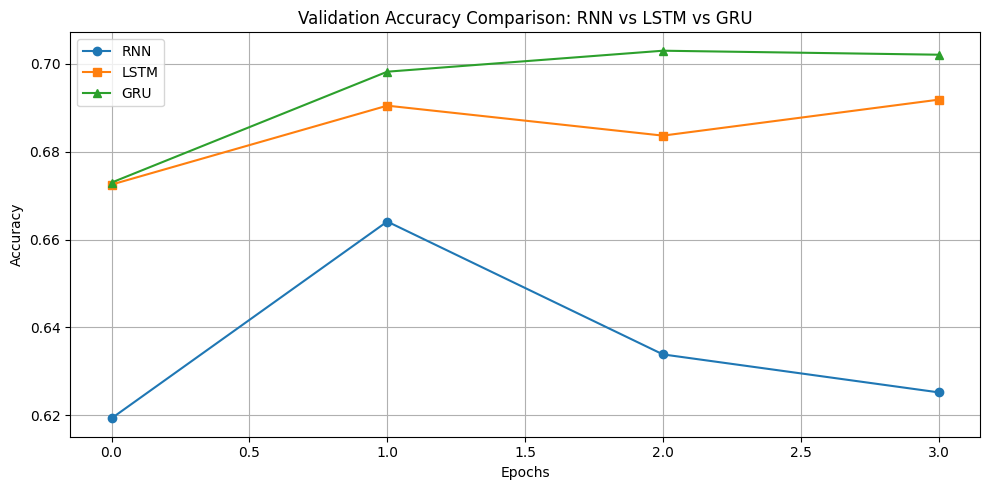

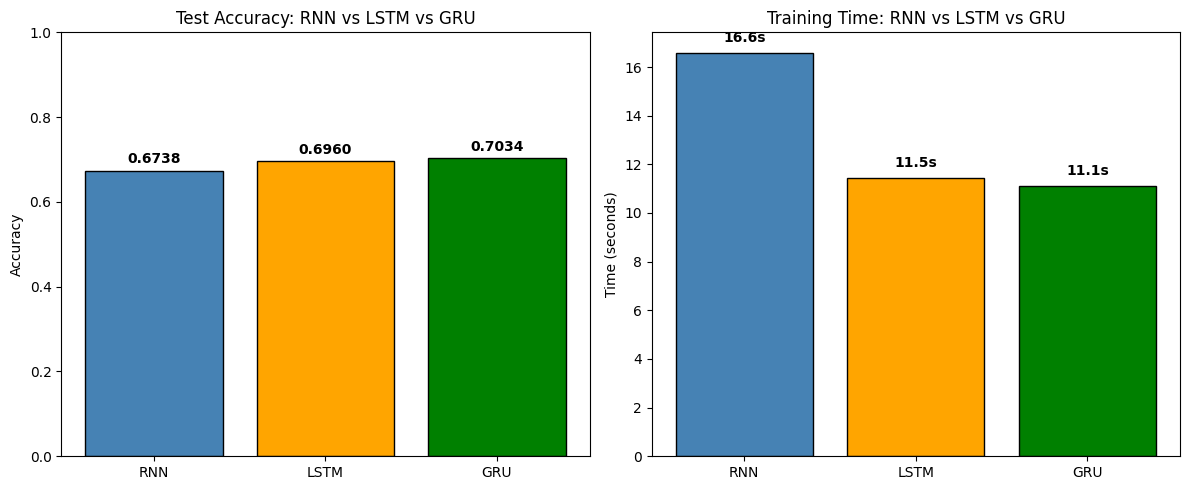

In [27]:
import matplotlib.pyplot as plt

# --- Plot 1: Validation Accuracy over Epochs ---
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],  label='RNN',  marker='o')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM', marker='s')
plt.plot(history_gru.history['val_accuracy'],  label='GRU',  marker='^')
plt.title('Validation Accuracy Comparison: RNN vs LSTM vs GRU')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Bar chart comparison (Accuracy & Training Time) ---
models = ['RNN', 'LSTM', 'GRU']
accuracies = [rnn_acc, lstm_acc, gru_acc]
times = [rnn_time, lstm_time, gru_time]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy bar chart
bars1 = axes[0].bar(models, accuracies, color=['steelblue', 'orange', 'green'], edgecolor='black')
axes[0].set_title('Test Accuracy: RNN vs LSTM vs GRU')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

# Training time bar chart
bars2 = axes[1].bar(models, times, color=['steelblue', 'orange', 'green'], edgecolor='black')
axes[1].set_title('Training Time: RNN vs LSTM vs GRU')
axes[1].set_ylabel('Time (seconds)')
for bar, tm in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{tm:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()